![alt text](STAR_MELT_logo.png "STAR_MELT")

# STAR-MELT FLUX forbidden lines component fitting

In [20]:
#Packages required by STAR-MELT, some are not used directly in this notebook, but called by the modules, check that they are all installed here
import time
from matplotlib import *
from matplotlib.pyplot import *
import numpy as np
import pandas as pd
import astropy
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.stats import sigma_clip
from astroquery.simbad import Simbad
from astropy.timeseries import LombScargle
import numpy.ma as ma
import os
from PyAstronomy import pyasl
from lmfit.models import GaussianModel, LinearModel
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit 
from scipy.signal import savgol_filter
from scipy.signal import find_peaks_cwt
from scipy.signal import argrelextrema

from star_melt import *


from ipywidgets import interact, interactive, fixed, interact_manual, Layout
import ipywidgets as widget
from IPython.display import display,clear_output,Image
import qgridnext as qgrid


#### If you change which %matplotlib magic command here you must restart the notebook

In [21]:
#for notebook/slides
#%matplotlib notebook 
#for lab
%matplotlib widget
#for new window plots
#%matplotlib qt

In [22]:
rcParams.update({'figure.max_open_warning': 50})
rcParams['figure.dpi'] = 100
matplotlib.rc('font', family='sans',size=14)
USH.fig_size_s=(6,5)
USH.fig_size_l=(9,5)
USH.fig_size_n=(9,3)

In [23]:
# The line table used in the emission line matching will be automatically selected 
# depending on which instrument is selected. This block is just to view the line list.
line_table=USH.line_table
line_table=USH.line_table_prev_obs

pd.set_option('display.max_rows', 50)

#line_table[(line_table.element=='C') & (line_table.obs_wl_air > 3000) & (line_table.obs_wl_air < 10000) & (line_table.Type)]
#line_table[ (line_table.obs_wl_air > 6310) & (line_table.obs_wl_air < 6330)]
line_table_FEL=line_table[(line_table.element=='O') & (line_table.obs_wl_air > 3770) & (line_table.obs_wl_air < 10000) & (line_table.Type)]
line_table_FEL#[line_table_FEL.Aki <0.1]
qgrid_widget1 = qgrid.show_grid(line_table, show_toolbar=False,grid_options={'forceFitColumns': False, 'defaultColumnWidth': 75})
display(qgrid_widget1)

QgridWidget(grid_options={'fullWidthRows': True, 'syncColumnCellResize': True, 'forceFitColumns': False, 'defa…

### Select star from available data

* Data should be organised as /STAR/INSTRUMENT/spectrum.fits or STAR/spectrum.fits
* Can run organise_fits_files(dir_of_files,output_dir) on dir_of_files containing .fits files that can be read by the read in scripts (example block near end of notebook)

In [24]:
data_dir='/Users/jcampbel/Library/CloudStorage/OneDrive-ESO/PEN_SM_phot_rm_backup_files/phot_rm_best_fit_fits/'



star_list=os.listdir(data_dir)
try:
    star_list.remove('.DS_Store')#remove temp file on mac because python will think it's a star!
except:
    pass


star_select = widget.Dropdown(
    options=sorted(star_list),
    #value='PDS 70',
    description='Select star:',
)
display(star_select)


Dropdown(description='Select star:', options=('Cha1', 'ECha', 'Lupus', 'Monitoring', 'OB1', 'OI_Vary', 'Taurus…

### Find closest standard star by checking spectral types on SIMBAD, get radial velocity of standard star

* Look up star in SIMBAD and get spectral type 
* Match to closest spectral type template star from available data in standards_dir
* Retrieve radial velocity and Vsini of template star
* If simbad_out=True, also return simbad query table

In [25]:
target=star_select.value
data_fits_files=get_files(os.path.join(data_dir,target),'.fits','.FTZ')
#standard_fits_files,mk,stype,st_rv,simbad=get_fits_files_simbad(target,standards_dir,simbad_out=True)

In [7]:
#in case you want to load all fits files within data_dir, uncomment the line below

#data_fits_files=get_files(os.path.join(data_dir),'.fits','.FTZ')



### Read in data and see what data is available for target star

In [26]:
data_dates_range2,instrument,w0=get_instrument_date_details(data_fits_files,qgrid=True)
#data_dates_range2.query("inst == 'ESPRESSO_SM' or inst == 'ROTFIT' and wmin > 625 and wmax < 640",inplace=True)
data_dates_range2

,target,utc,mjd,inst,wmin,wmax,bary,snr,file
0,CHX 18N,59332.04870534,59332.048705,ESPRESSO_SM,6667.67,6747.65,N/A,N/A,/Users/jcampbel/Library/CloudStorage/OneDrive-...
1,CHX 18N,59332.04870534,59332.048705,ESPRESSO_SM,6512.68,6612.65,N/A,N/A,/Users/jcampbel/Library/CloudStorage/OneDrive-...
2,CHX 18N,59332.04870534,59332.048705,ESPRESSO_SM,5546.71,5606.68,N/A,N/A,/Users/jcampbel/Library/CloudStorage/OneDrive-...
3,CHX 18N,59332.04870534,59332.048705,ESPRESSO_SM,6269.70,6329.68,N/A,N/A,/Users/jcampbel/Library/CloudStorage/OneDrive-...
4,CHX 18N,59332.04870534,59332.048705,ESPRESSO_SM,6332.68,6392.66,N/A,N/A,/Users/jcampbel/Library/CloudStorage/OneDrive-...
...,...,...,...,...,...,...,...,...,...
165,V WZ Cha,59753.981477675,59753.981478,UVES_SM,6333.91,6393.90,N/A,N/A,/Users/jcampbel/Library/CloudStorage/OneDrive-...
166,V WZ Cha,59753.981477675,59753.981478,UVES_SM,6668.96,6748.95,N/A,N/A,/Users/jcampbel/Library/CloudStorage/OneDrive-...
167,V WZ Cha,59753.981477675,59753.981478,UVES_SM,6513.93,6613.93,N/A,N/A,/Users/jcampbel/Library/CloudStorage/OneDrive-...
168,V WZ Cha,59753.981477675,59753.981478,UVES_SM,5546.73,5606.71,N/A,N/A,/Users/jcampbel/Library/CloudStorage/OneDrive-...


In [29]:
line_sel=widget.FloatText(value='6730.82',step=10,description='Line centre',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
line_sel=widget.Select(options=[4861.3,6300.3,6363.78,5577.34,6583.45,6730.82],value=6300.3,description='Line centre',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
range_sel=widget.FloatText(value='30',step=5,description='Wavelength range (AA)',layout={'width': 'max-content'}, style = {'description_width': 'initial'})

display(widget.HBox([line_sel,range_sel]))

In [30]:
target_select = widget.SelectMultiple(options=unique(data_dates_range2.target),value=[data_dates_range2.target.iloc[0]],description='Select target(s):',style = {'description_width': 'initial'})
display(target_select)

SelectMultiple(description='Select target(s):', index=(2,), options=('Ass Cha T 1-32', 'Ass Cha T 1-8', 'CHX 1…

In [31]:
data_dates_range1=data_dates_range2[data_dates_range2.target.isin(target_select.value)]
inst_options=['any']
inst_options.extend(unique(data_dates_range1.inst).tolist())
inst_select = widget.RadioButtons(
    options=inst_options,
    description='Instrument selection:',
    style = {'description_width': 'initial'}
)
display(inst_select)

RadioButtons(description='Instrument selection:', options=('any', 'ESPRESSO_SM'), style=DescriptionStyle(descr…

In [32]:
data_dates_range3=data_dates_range1
if inst_select.value!='any':
    data_dates_range3=data_dates_range1[data_dates_range1.inst==inst_select.value]

obs_options=['all']  
obs_options.extend(data_dates_range3.utc)
obs_select = widget.SelectMultiple(
    options=obs_options,
    value=['all'],
    description='obs selection:',
    style = {'description_width': 'initial'}
)
display(obs_select)

SelectMultiple(description='obs selection:', index=(0,), options=('all', '59349.05646741', '59349.05646741', '…

In [33]:
data_dates_range3=data_dates_range1
if inst_select.value!='any':
    data_dates_range3=data_dates_range1[data_dates_range1.inst==inst_select.value]

obs_options=['all']  
obs_options.extend(data_dates_range3.file)
obs_select = widget.SelectMultiple(
    options=obs_options,
    value=['all'],
    description='obs selection:',
    style = {'description_width': 'initial'},
    layout={'width': 'max-content'}
)
display(obs_select)

SelectMultiple(description='obs selection:', index=(0,), layout=Layout(width='max-content'), options=('all', '…

In [34]:
data_dates_range4=data_dates_range3
if obs_select.value[0]!='all':
    data_dates_range4=data_dates_range3[data_dates_range3.file.isin(obs_select.value)]

data_dates_range4=data_dates_range4[(data_dates_range4.wmin < line_sel.value) & (data_dates_range4.wmax > line_sel.value)]

all_inst=True if len(unique(data_dates_range4.inst)) >1 else False

data_dates_range,instrument,w0=get_instrument_date_details(data_dates_range4.file,inst_select.value,
                                                           all_inst=all_inst,qgrid=False,w_range_auto=False)#,start_date='2008',end_date='2012')
data_dates_range.sort_values('target',inplace=True)
data_dates_range

-data available from selected instrument:ESPRESSO_SM -


,target,utc,mjd,inst,wmin,wmax,bary,snr,file
0,Ass Cha T 1-32,59349.05646741,59349.056467,ESPRESSO_SM,6269.72,6329.69,N/A,N/A,/Users/jcampbel/Library/CloudStorage/OneDrive-...
1,Ass Cha T 1-32,59350.00533879,59350.005339,ESPRESSO_SM,6269.71,6329.69,N/A,N/A,/Users/jcampbel/Library/CloudStorage/OneDrive-...


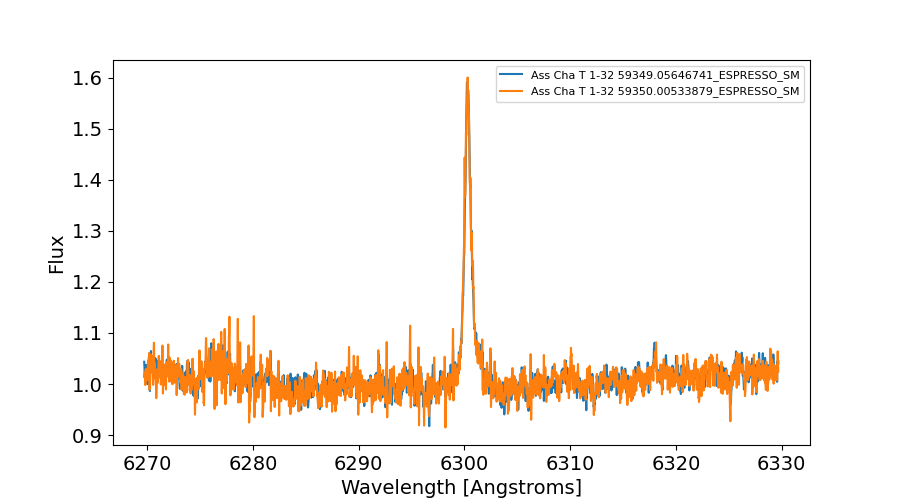

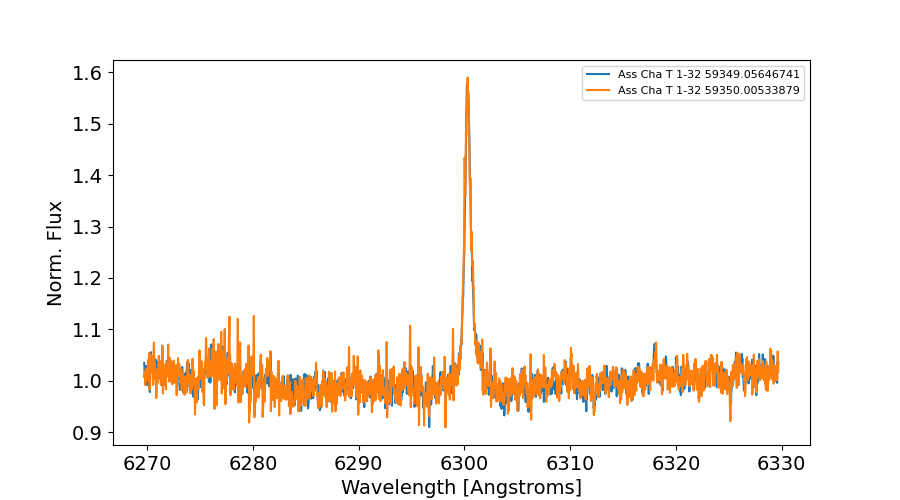

In [35]:
df_av=get_av_spec(data_dates_range,w0,norm=False,output=True,plot_av=False,savefig=False,label='utc_inst')
df_av_norm=get_av_spec(data_dates_range,w0,norm=True,output=True,plot_av=False)#,label='utc_inst')
USH.target=data_dates_range.target[0]
USH.instrument=unique(data_dates_range['inst'])

Ass Cha T 1-32
['ESPRESSO_SM']


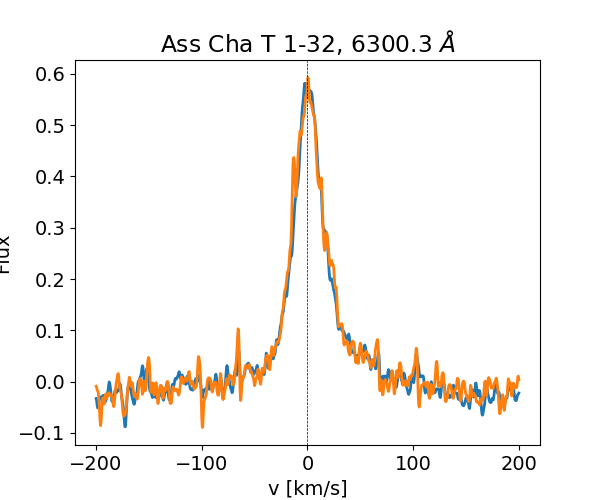

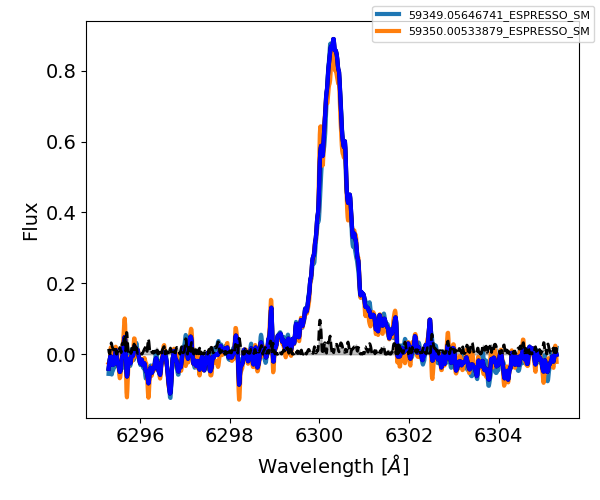

In [36]:
line=line_sel.value
#line=6567
radvel=0
vel_range=200
w_range=5
df_av_line_vel=get_line_spec(df_av,line,vel_range,vel_offset=radvel,vel=True,cont_sub=True,full_norm=False,norm=True) #can set vel_offset to rv
vel_plot(df_av_line_vel,line=line,plot_av=False,plot_sd=False,fs=USH.fig_size_s,legend=False)

df_av_line=get_line_spec(df_av,line,w_range,vel_offset=radvel,vel=False,cont_sub=True,norm=False,full_norm=True)
wl_plot(df_av_line,plot_av=True,plot_sd=True,fs=USH.fig_size_s,legend=True)

#offset_wl_plot(df_av_norm)

### FEL velocity components fitting options



In [ ]:
target=USH.target
line=line_sel.value
line_select = widget.FloatText(value=line,step=1,description='Line wavelength (A)',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
rv_select = widget.FloatText(value=0,step=1,description='Star Radial Velocity (km/s)',layout={'width': 'max-content'}, style = {'description_width': 'initial'})

#date_selector = widget.SelectMultiple(options=df_av.columns[1:-1],value=['med_flux'],description='Select dates:',)
columns_list = list(df_av.columns[1:-1])  # Selecting columns from the 2nd to the last excluding the first and last
#columns_list.pop(-2)
default_selection = columns_list[:-2]
date_selector = widgets.SelectMultiple(options=columns_list,value=default_selection,description='Select dates:')
display(widget.HBox([line_select,rv_select,date_selector]))

vel_range=widget.FloatText(value='200',step=10,description='Velocity window',layout={'width': 'max-content'}, style = {'description_width': 'initial'})

fit_nc=widget.Checkbox(value=True,description='Fit SC/NC?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
fit_bc=widget.Checkbox(value=False,description='Fit BC?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
fit_hvc_b=widget.Checkbox(value=False,description='Fit HVC blue?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
fit_hvc_r=widget.Checkbox(value=False,description='Fit HVC red?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})

gof_min_sel=widget.FloatSlider(min=0.1, max=1, step=0.1,value=0.2,description='GoF min:', style = {'description_width': 'initial'})
reject_low_gof=widget.Checkbox(value=False,description='Use min GoF?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
reject_line_close=widget.Checkbox(value=False,description='Use min std err?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})

set_g1_cen=widget.Checkbox(value=True,description='Set NC centre limits?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
set_g1_sig=widget.Checkbox(value=False,description='Set NC FWHM limits?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g1_cen_min=widget.FloatText(value='-30',step=10,description='NC centre min',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g1_cen_max=widget.FloatText(value='30',step=10,description='max',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g1_sig_min=widget.FloatText(value='0',step=10,description='NC sigma min',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g1_sig_max=widget.FloatText(value='40',step=10,description='max',layout={'width': 'max-content'}, style = {'description_width': 'initial'})

set_g2_cen=widget.Checkbox(value=True,description='Set BC centre limits?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
set_g2_sig=widget.Checkbox(value=False,description='Set BC FWHM limits?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g2_cen_min=widget.FloatText(value='-30',step=10,description='BC centre min',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g2_cen_max=widget.FloatText(value='30',step=10,description='max',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g2_sig_min=widget.FloatText(value='40',step=10,description='BC sigma min',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g2_sig_max=widget.FloatText(value='300',step=10,description='max',layout={'width': 'max-content'}, style = {'description_width': 'initial'})

set_g3_cen=widget.Checkbox(value=True,description='Set HVC blue centre limits?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
set_g3_sig=widget.Checkbox(value=False,description='Set HVC blue FWHM limits?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g3_cen_min=widget.FloatText(value='-200',step=10,description='HVC_b centre min',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g3_cen_max=widget.FloatText(value='-30',step=10,description='max',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g3_sig_min=widget.FloatText(value='0',step=10,description='HVC_b FWHM min',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g3_sig_max=widget.FloatText(value='300',step=10,description='max',layout={'width': 'max-content'}, style = {'description_width': 'initial'})

set_g4_cen=widget.Checkbox(value=True,description='Set HVC red centre limits?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
set_g4_sig=widget.Checkbox(value=False,description='Set HVC red FWHM limits?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g4_cen_min=widget.FloatText(value='30',step=10,description='HVC red min',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g4_cen_max=widget.FloatText(value='200',step=10,description='max',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g4_sig_min=widget.FloatText(value='0',step=10,description='HVC red min',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
g4_sig_max=widget.FloatText(value='300',step=10,description='max',layout={'width': 'max-content'}, style = {'description_width': 'initial'})

savefig=widget.Checkbox(value=False,description='Save all output plots to file?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
title=widget.Dropdown(options=['full','simple','none'],value='none',description='Plot title',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
df_sel=widget.Dropdown(options=['df_av','df_av_sub','df_av_norm'],value='df_av',description='Use df_av or df_av_norm?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})

savefile=widget.Checkbox(value=False,description='Save all results plots to output file?',layout={'width': 'max-content'}, style = {'description_width': 'initial'})
filename_sel=widget.Text(value='FEL_fit_params/OI_vary_fit_results.csv',description='enter filename:',layout={'width': 'max-content'}, style = {'description_width': 'initial'})

display(df_sel,vel_range)
display(widget.TwoByTwoLayout(top_left=widget.HBox([reject_low_gof,reject_line_close]),top_right=gof_min_sel,bottom_left=widget.HBox([fit_nc,fit_bc,fit_hvc_b]),bottom_right=widget.HBox([fit_hvc_r])))
display(widget.TwoByTwoLayout(bottom_left=widget.HBox([g1_cen_min,g1_cen_max]),bottom_right=widget.HBox([g1_sig_min,g1_sig_max]),top_left=set_g1_cen,top_right=set_g1_sig))
display(widget.TwoByTwoLayout(bottom_left=widget.HBox([g2_cen_min,g2_cen_max]),bottom_right=widget.HBox([g2_sig_min,g2_sig_max]),top_left=set_g2_cen,top_right=set_g2_sig))
display(widget.TwoByTwoLayout(bottom_left=widget.HBox([g3_cen_min,g3_cen_max]),bottom_right=widget.HBox([g3_sig_min,g3_sig_max]),top_left=set_g3_cen,top_right=set_g3_sig))
display(widget.TwoByTwoLayout(bottom_left=widget.HBox([g4_cen_min,g4_cen_max]),bottom_right=widget.HBox([g4_sig_min,g4_sig_max]),top_left=set_g4_cen,top_right=set_g4_sig))
display(widget.HBox([title,savefig]))
display(widget.HBox([savefile,filename_sel]))

Dropdown(description='Use df_av or df_av_norm?', layout=Layout(width='max-content'), options=('df_av', 'df_av_…

FloatText(value=200.0, description='Velocity window', layout=Layout(width='max-content'), step=10.0, style=Des…

TwoByTwoLayout(children=(HBox(children=(Checkbox(value=False, description='Use min GoF?', layout=Layout(width=…

TwoByTwoLayout(children=(Checkbox(value=True, description='Set NC centre limits?', layout=Layout(grid_area='to…

TwoByTwoLayout(children=(Checkbox(value=True, description='Set BC centre limits?', layout=Layout(grid_area='to…

TwoByTwoLayout(children=(Checkbox(value=True, description='Set HVC blue centre limits?', layout=Layout(grid_ar…

TwoByTwoLayout(children=(Checkbox(value=True, description='Set HVC red centre limits?', layout=Layout(grid_are…

## Fit the lines

attempting fit of line at  6300.3
number of dates attempting to fit 2
Velocity at 50% of total integrated flux: 2.56 km/s


/Users/jcampbel/Dropbox/PDRA/STFC_project/STAR_MELT_git/.venv/lib/python3.13/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


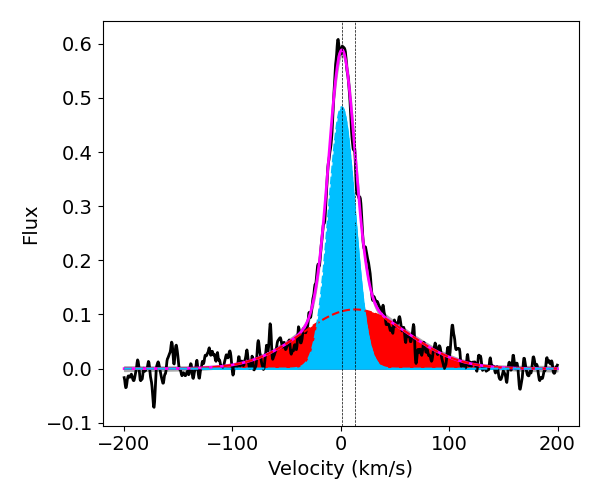

Velocity at 50% of total integrated flux: 1.87 km/s


/Users/jcampbel/Dropbox/PDRA/STFC_project/STAR_MELT_git/.venv/lib/python3.13/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


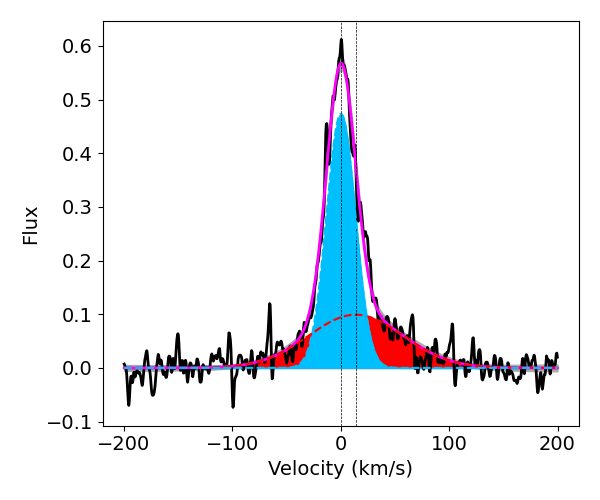

In [38]:
line_date_list=date_selector.value
line=line_select.value
radvel=rv_select.value
print('attempting fit of line at ',line)
print('number of dates attempting to fit %s'%(len(line_date_list)))

nc_cen=[g1_cen_min.value,g1_cen_max.value] if set_g1_cen.value==True else None
bc_cen=[g2_cen_min.value,g2_cen_max.value] if set_g2_cen.value==True else None
hvc1_cen=[g3_cen_min.value,g3_cen_max.value] if set_g3_cen.value==True else None 
hvcr_cen=[g4_cen_min.value,g4_cen_max.value] if set_g4_cen.value==True else None 
nc_sig=[g1_sig_min.value/2.355,g1_sig_max.value/2.355] if set_g1_sig.value==True else None 
bc_sig=[g2_sig_min.value/2.355,g2_sig_max.value/2.355] if set_g2_sig.value==True else None 
hvc1_sig=[g3_sig_min.value/2.355,g3_sig_max.value/2.355] if set_g3_sig.value==True else None 
hvcr_sig=[g4_sig_min.value/2.355,g4_sig_max.value/2.355] if set_g4_sig.value==True else None 

df_fit=df_av if df_sel.value=='df_av' else df_av_norm if df_sel.value=='df_av_norm' else df_av_sub
#df_fit=df_av_low_res
df_av_line_vel=get_line_spec(df_fit,line,vel_range.value,vel_offset=radvel,vel=True)
line_results=pd.DataFrame()

##########################
#df_av_line_vel=df_av_line_vel.query('vel < -25 or vel > -18')
#df_av_line_vel=df_av_line_vel.query('vel > -500 and vel < 135')

##########################


for date in date_selector.value:
    #     # Retrieve the corresponding target for the current date
    # try:
    #     target = df_av_line_vel[df_av_line_vel[date] == (date)]['target'].values[0]
    # except KeyError:
    #     # If 'mjd' is not available, use another column like 'utc' or adjust as needed
    #     target = df_fit[df_fit['utc'] == date]['target'].values[0]

    # Call gauss_stats_ab19 with the dynamically retrieved target
    out,x,y,line_info=gauss_stats_ab19(df_av_line_vel,date,em_row=line,target=target,
                                          gof_min=gof_min_sel.value,printout=False,output=True,savefig=savefig.value,title=title.value,
                                          reject_low_gof=reject_low_gof.value,reject_line_close=reject_line_close.value,plot_comps=True,
                                          fit_nc=fit_nc.value,fit_bc=fit_bc.value,fit_hvc1=fit_hvc_b.value,fit_hvcr=fit_hvc_r.value,nc_cen=nc_cen,bc_cen=bc_cen,hvc1_cen=hvc1_cen,
                                          hvcr_cen=hvcr_cen,nc_sig=nc_sig,bc_sig=bc_sig,hvc1_sig=hvc1_sig,hvcr_sig=hvcr_sig,legend=False)
    line_results=pd.concat([line_results,line_info],axis=1,ignore_index=True)
line_results=line_results.T  


if savefile.value==True:
    timenow_bu=time.strftime("%d_%b_%Y_%H_%M", time.gmtime())
    filename=filename_sel.value
    #if os.path.exists(filename):
    #    os.system('cp %s backups/%s/'%(filename,timenow_bu+filename))
    line_results.to_csv(filename, mode='a', header=not os.path.exists(filename),index=False)
    print('saving results to output file: ',filename)



In [82]:
pd.set_option('display.max_columns', None)

In [39]:
line_results

,star,mjd,line,int_flux,EW,SNR,med_cont,gof,peak,asym,...,hvc1_fwhm_stderr,hvc1_amp,hvc1_amp_stderr,hvcr_cen,hvcr_stderr,hvcr_fwhm,hvcr_fwhm_stderr,hvcr_amp,hvcr_amp_stderr,half_flux_velocity
0,Ass Cha T 1-32,59349.05646741_ESPRESSO_SM,6300.3,5.8378,0.593474,113.65828,0.983668,0.016409,0.586663,0.429685,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.56228
1,Ass Cha T 1-32,59350.00533879_ESPRESSO_SM,6300.3,5.5904,0.565716,75.1316,0.988206,0.029632,0.567701,0.442043,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.871444


### Extra functions

finding rv of all stars in dir

In [ ]:
line=6000
rv_list=[]
#for star in star_list: #loop through all stars in data_dir
target='PEN_ESP_ClassIII'
data_fits_files=get_files(os.path.join(data_dir,target),'.fits','.FTZ') #get filenames of .fits files
data_dates_range1,instrument,w0=get_instrument_date_details(data_fits_files,qgrid=True) #get instrument details so that we can find which ones cover Halpha

for target in data_dates_range1.target:
    new_list=data_dates_range1[data_dates_range1.target==target]
    if new_list.iloc[0].wmin < (line/10)-5 and new_list.iloc[0].wmax > (line/10)+5: #check data covers line
        USH.target=star #for figure filenames
        USH.instrument=new_list.iloc[0].inst #for figure filenames
        data_dates_range,instrument,w0=get_instrument_date_details(new_list.file,qgrid=False) #select obs
        df_av=get_av_spec(data_dates_range,w0,norm=False,output=False,plot_av=True,savefig=False)#,label='utc_inst')
        #df_av_norm=get_av_spec(data_dates_range,w0,norm=True,output=False,plot_av=True,label='utc_inst') #get av spec
        if target.startswith('V '):
            target=target.replace('V ', '', 1)
        standard_fits_files,mk,stype,st_rv,simbad=get_fits_files_simbad(target,standards_dir,simbad_out=True) #check name is resolved in SIMBAD, only used for printing for now but can be used to get RV if fitting added here
        st_info,st_wave,st_flux,st_err=read_fits_files(standard_fits_files[0],verbose=False) 
        radvel,rv_err,vsini,vsini_err=get_rv_vsini(df_av,st_wave,st_flux,st_rv,date='med_flux',w_min=5800,w_max=6200,output=False,rtn_err=True)
        rv_list.append([target,mk,radvel,np.round(rv_err,2),vsini,np.round(vsini_err,2)])
rv_df = pd.DataFrame(rv_list, columns=["star","SpT","rv","rv_err","vsini","vsini_err"])


In [30]:
rv_df

,star,SpT,rv,rv_err,vsini,vsini_err
0,HD 285957,K2,18.8,0.00,4.82,0.00
1,EL Cha,M2,18.0,0.09,13.73,0.66
2,RX J1538.6-3916,K4,2.8,0.00,7.71,0.01
3,2MASS J15430624-3920194,K6,5.2,0.00,7.60,0.01
4,V1077 Tau,G8,18.0,0.00,9.55,0.01
5,V1191 Sco,M6.5,-3.6,0.68,11.66,0.44
6,V1249 Cen,M0.5,7.6,0.06,9.79,0.04
7,MW Lup,K7,2.8,0.00,10.13,0.03
8,2MASS J15552621-3338232,K5,0.8,0.00,6.58,0.01
9,CD-36 7429B,M1V,12.4,0.00,11.22,0.00
